In [3]:
# importing libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Datos Geoespaciales

Vector:
- Puntos
- lineas
- poligonos

Se representan en tablas:

Filas: observaciones
Columnas: características, incluyendo localización (coordenadas y geometría).

Para manejarla se usa geopandas

# Importando la data

Data geoespacial (gdf)

In [ ]:
gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")
gdf.info()

In [68]:
# Reading local file
gdf = gpd.read_file("./df_catchments_spatial.gpkg")
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   526 non-null    int64   
 1   Nombre               526 non-null    str     
 2   ID_CUENCA            526 non-null    float64 
 3   cuenca               526 non-null    str     
 4   area                 526 non-null    int64   
 5   elev_mean            526 non-null    float64 
 6   elev_median          526 non-null    float64 
 7   rel_mean             526 non-null    float64 
 8   rel_median           526 non-null    float64 
 9   rainfallAnnual_mean  526 non-null    float64 
 10  Densidad             526 non-null    float64 
 11  hypso_inte           526 non-null    float64 
 12  slope_mean           526 non-null    float64 
 13  kmeans               526 non-null    str     
 14  RainfallDaysmean     526 non-null    float64 
 15  RainfallDaysmed

In [97]:
gdf.head()

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,Densidad,hypso_inte,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,18.230950,0.493,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.74 622820.251, 454684.825 622..."
1,2,Quebrada Cabaña,601.0,Cauca,15797104,1485.514279,1443.0,587.551540,590.0,2453.187233,15.837190,0.515,27.276356,C,1381.331112,1416.0,grass,volcanic,6.0,"POLYGON ((445998.99 633523.601, 445938.99 6334..."
2,3,Quebrada Circia,268.0,Cauca,41264565,1751.017810,1771.0,479.273145,482.0,2446.462791,17.364213,0.534,27.046340,C,1335.000000,1335.0,grass,granitic,6.0,"POLYGON ((449407.484 638933.816, 449416.943 63..."
3,4,Quebrada Las Yeguas,257.0,Cauca,86871930,2259.304383,2235.0,290.758334,250.0,2415.640307,12.902091,0.636,19.844786,D,1342.000000,1302.5,grass,granitic,8.0,"POLYGON ((449127.882 648864.822, 449150.88 648..."
4,5,Quebrada Daza,255.0,Cauca,28178836,1671.334481,1660.0,488.840365,499.0,2361.272164,22.018253,0.500,28.240738,C,1186.297521,1268.5,grass,granitic,6.0,"POLYGON ((445769.984 646158.816, 445776.576 64..."


In [32]:
firstGeometry = gdf.iloc[0].geometry
print(firstGeometry)

POLYGON ((454732.7401999999 622820.2511, 454684.82519999985 622512.7511, 454632.3690999998 622416.2179000005, 454639.70799999963 622293.1416999996, 454517.2910000002 622215.2999000009, 454464.48340000026 622100.2217999995, 454265.79200000037 622063.1612999998, 454130.67480000015 621911.9308000002, 454051.45600000024 621841.1494999994, 454008.9901999999 621793.6007000003, 453977.2910000002 621765.2999000009, 453963.1405999996 621749.4503000006, 453922.9079 621758.0471000001, 453875.52830000035 621768.1710000001, 453812.8738000002 621764.4416000005, 453746.0800999999 621760.4659000002, 453689.06989999954 621780.9181999993, 453673.1085999999 621798.7820999995, 453638.37959999964 621814.7245000005, 453599.0608000001 621836.0867999997, 453586.91559999995 621854.4398999996, 453577.9770999998 621873.9199999999, 453558.9901999999 621915.2999000009, 453435.36089999974 622065.9814999998, 453388.7335999999 622063.2107999995, 453332.4835999999 622066.5556000005, 453275.09140000027 622063.130999999

In [55]:
cuencas = gdf['cuenca'].unique()
gdf_filtered = gdf[gdf["cuenca"].isin(cuencas)]
gdf_filtered

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,Densidad,hypso_inte,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,18.230950,0.493,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.74 622820.251, 454684.825 622..."
1,2,Quebrada Cabaña,601.0,Cauca,15797104,1485.514279,1443.0,587.551540,590.0,2453.187233,15.837190,0.515,27.276356,C,1381.331112,1416.0,grass,volcanic,6.0,"POLYGON ((445998.99 633523.601, 445938.99 6334..."
2,3,Quebrada Circia,268.0,Cauca,41264565,1751.017810,1771.0,479.273145,482.0,2446.462791,17.364213,0.534,27.046340,C,1335.000000,1335.0,grass,granitic,6.0,"POLYGON ((449407.484 638933.816, 449416.943 63..."
3,4,Quebrada Las Yeguas,257.0,Cauca,86871930,2259.304383,2235.0,290.758334,250.0,2415.640307,12.902091,0.636,19.844786,D,1342.000000,1302.5,grass,granitic,8.0,"POLYGON ((449127.882 648864.822, 449150.88 648..."
4,5,Quebrada Daza,255.0,Cauca,28178836,1671.334481,1660.0,488.840365,499.0,2361.272164,22.018253,0.500,28.240738,C,1186.297521,1268.5,grass,granitic,6.0,"POLYGON ((445769.984 646158.816, 445776.576 64..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,522,Río Perrillo,636.0,Magdalena,160115721,2847.620092,2780.0,431.423517,417.0,1948.196227,13.119450,0.520,26.855814,C,1015.000000,1063.0,forest,sediment,138.0,"POLYGON ((465388.904 573489.562, 465389.691 57..."
522,523,Quebrada Colorada,638.0,Cauca,15291347,784.887030,772.0,159.363335,152.0,3205.125970,12.041626,0.407,14.709435,B,1953.206900,1934.0,forest,granitic,0.0,"POLYGON ((556981.053 845778.922, 557081.043 84..."
523,524,Río Encarnación,642.0,Atrato,216936174,2474.474558,2468.0,385.560438,351.0,2406.534741,17.758762,0.439,25.675008,C,1272.000000,1317.0,forest,volcanic,18.0,"POLYGON ((372088.827 728377.954, 372209.412 72..."
524,525,Río Guadalupe,648.0,Cauca,464103351,2162.844317,2204.0,185.479280,133.0,2879.729330,7.637781,0.667,15.516188,D,1964.631579,2030.0,grass,granitic,166.0,"POLYGON ((477058.141 758171.375, 477058.141 75..."


In [63]:
gdf.groupby("cuenca")["Nombre"].nunique()


cuenca
Atrato       127
Cauca        264
Magdalena    129
Name: Nombre, dtype: int64

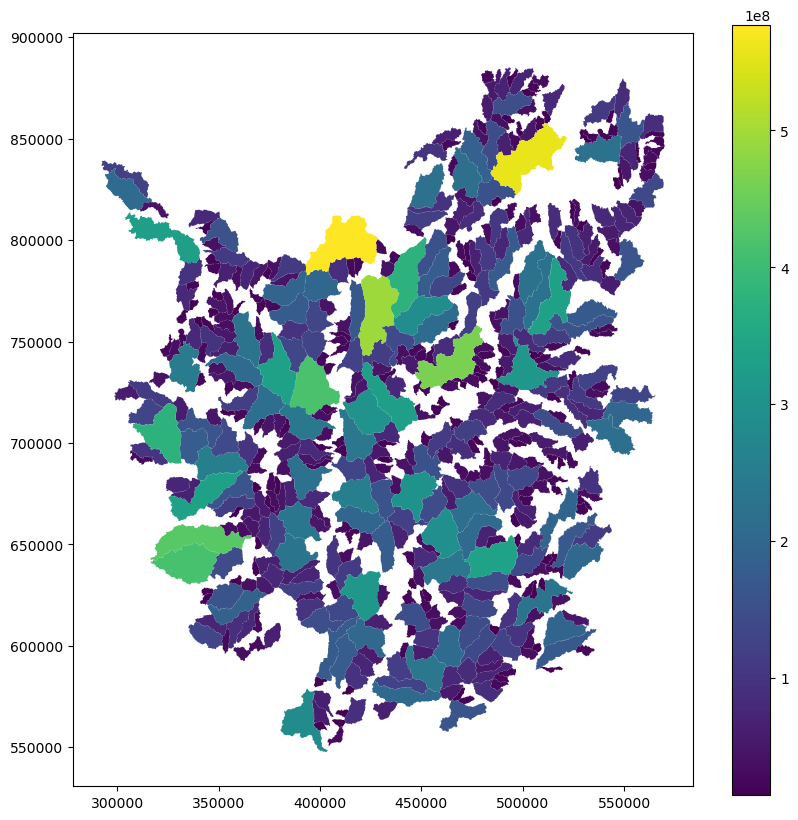

In [50]:
f, ax = plt.subplots(1, figsize=(10, 10))
gdf.plot(column='area', legend=True, ax=ax)
plt.show()

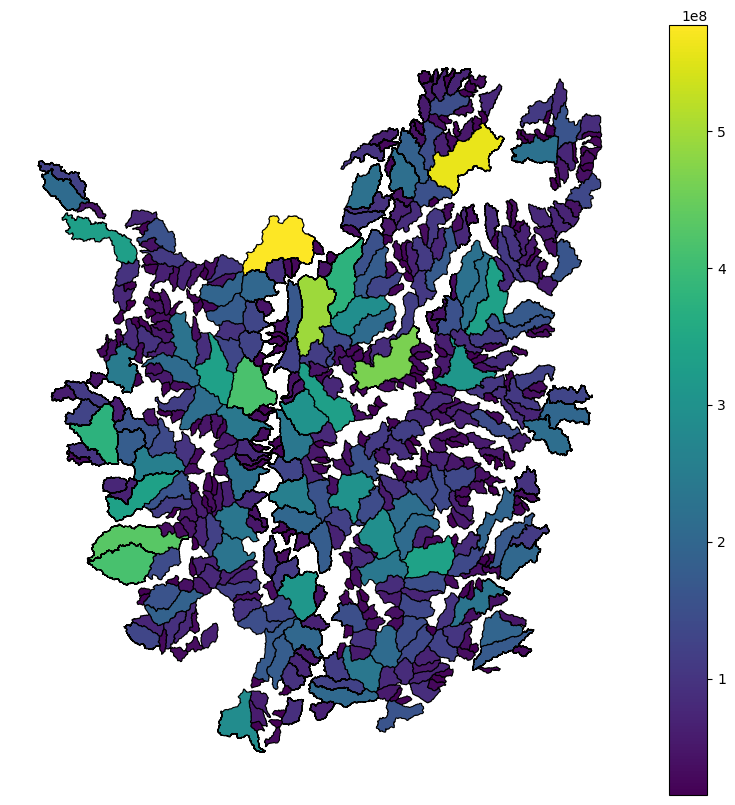

In [51]:
f, ax = plt.subplots(1, figsize=(10, 10))

gdf.plot(
    column="area",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.8
)

ax.set_axis_off()
plt.show()


# Convirtiendo dataframe a geoDataframe

In [86]:
# Example
df = pd.DataFrame({
  'City': ['Buenos Aires', 'Brasilia', 'Santiago', 'Bogota', 'Caracas'],
  'Country': ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Venezuela'],
  'Latitude': [-34.58, -15.78, -33.45, 4.60, 10.48],
  'Longitude': [-58.66, -47.91, -70.66, -74.08, -66.86]
})

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   City       5 non-null      str    
 1   Country    5 non-null      str    
 2   Latitude   5 non-null      float64
 3   Longitude  5 non-null      float64
dtypes: float64(2), str(2)
memory usage: 292.0 bytes


In [88]:
df.head()

,City,Country,Latitude,Longitude
0,Buenos Aires,Argentina,-34.58,-58.66
1,Brasilia,Brazil,-15.78,-47.91
2,Santiago,Chile,-33.45,-70.66
3,Bogota,Colombia,4.60,-74.08
4,Caracas,Venezuela,10.48,-66.86


In [93]:
# Creating coordinates tuple
df['Coordinates'] = list(zip(df.Longitude, df.Latitude))
df

,City,Country,Latitude,Longitude,Coordinates
0,Buenos Aires,Argentina,-34.58,-58.66,"(-58.66, -34.58)"
1,Brasilia,Brazil,-15.78,-47.91,"(-47.91, -15.78)"
2,Santiago,Chile,-33.45,-70.66,"(-70.66, -33.45)"
3,Bogota,Colombia,4.60,-74.08,"(-74.08, 4.6)"
4,Caracas,Venezuela,10.48,-66.86,"(-66.86, 10.48)"


In [94]:
# apply Point class to coordinates
from shapely.geometry import Point
df['Coordinates'] = df['Coordinates'].apply(Point)
df

,City,Country,Latitude,Longitude,Coordinates
0,Buenos Aires,Argentina,-34.58,-58.66,POINT (-58.66 -34.58)
1,Brasilia,Brazil,-15.78,-47.91,POINT (-47.91 -15.78)
2,Santiago,Chile,-33.45,-70.66,POINT (-70.66 -33.45)
3,Bogota,Colombia,4.60,-74.08,POINT (-74.08 4.6)
4,Caracas,Venezuela,10.48,-66.86,POINT (-66.86 10.48)


In [95]:
cities_gdf = gpd.GeoDataFrame(df, geometry='Coordinates')
cities_gdf

,City,Country,Latitude,Longitude,Coordinates
0,Buenos Aires,Argentina,-34.58,-58.66,POINT (-58.66 -34.58)
1,Brasilia,Brazil,-15.78,-47.91,POINT (-47.91 -15.78)
2,Santiago,Chile,-33.45,-70.66,POINT (-70.66 -33.45)
3,Bogota,Colombia,4.60,-74.08,POINT (-74.08 4.6)
4,Caracas,Venezuela,10.48,-66.86,POINT (-66.86 10.48)


<Axes: >

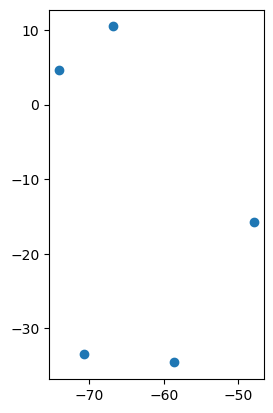

In [96]:
cities_gdf.plot()

En qué sistema de coordenadas está? Habrá forma de saber?

Elipsoide como representación de la tierra. Hay muchos elipsoides para representar la forma de la tierra, cada país tiene su elipsoide. WGS84.




Dos familias de sistemas de coordenaas

La tierra es irregular

Geoide

Otro sistema de coordenadas = Sistema de coordenadas planas (x,y). Se proyecta el elipsoide (una circunferencia) a un plano. Proyecciones (conos, cilindros)

Estandarizaron a Marcator transversal. Se dice en que parte está el país.

Colombia -> Magna sigma

Datum (sistema de coordenadas de los datos y el punto cero).

EPSG -> Estandarización

A los puntos se le pasa el sistema de coordenadas

Hay que decir el sistema de coordenas en la que están los datos, normalmente geograficos


Cuenca: Origen de los rios, es el area que representa el origen del rio, de donde se drena